In [1]:
# import relevant libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score
)


In [3]:
import warnings
warnings.filterwarnings('ignore')

In [4]:
import joblib

# Practical Training Order

Logistic Regression → baseline, interpretable

KNN

Decision Tree → check non-linear modeling

Random Forest → strong baseline ensemble

XGBoost / LightGBM → if you want top performance

# Introduction & Problem Statement

Diabetes is a chronic metabolic disorder that affects millions of people worldwide and is a leading cause of complications such as cardiovascular disease, kidney failure, and vision loss. Early detection and timely intervention are critical to reducing long-term health risks and healthcare costs. However, in many settings, especially resource-limited environments, access to advanced diagnostic tools may be limited.

This project aims to build a machine learning model that predicts the likelihood of diabetes using basic clinical screening data such as glucose level, body mass index (BMI), age, blood pressure, and insulin measurements. By analyzing patterns in these routinely collected variables, the model can help identify individuals who may be at higher risk of diabetes.

From a machine learning perspective, this task is formulated as a binary classification problem, where the goal is to classify patients into two categories: diabetic or non-diabetic. The model is designed as a decision-support tool, intended to assist healthcare professionals by providing risk insights rather than serving as a standalone diagnostic system. Emphasis is placed on minimizing missed diagnoses, as false negatives in diabetes screening can have serious clinical consequences.

# Dataset Overview

The dataset used in this project is the Pima Indians Diabetes Dataset, a well-known dataset in healthcare machine learning sourced from the UCI Machine Learning Repository. It contains clinical measurements collected from female patients of Pima Indian heritage, providing a realistic foundation for modeling diabetes risk.

Each row in the dataset represents a single patient, while each column captures specific clinical features, summarized as follows:

Feature	Description
Pregnancies	Number of times the patient has been pregnant
Glucose	Plasma glucose concentration (mg/dL)
BloodPressure	Diastolic blood pressure (mm Hg)
SkinThickness	Triceps skin fold thickness (mm)
Insulin	2-hour serum insulin (µU/mL)
BMI	Body Mass Index (weight in kg / height in m²)
DiabetesPedigreeFunction	Genetic diabetes risk score based on family history
Age	Age of the patient in years
Outcome	Target variable: 1 = diabetic, 0 = non-diabetic

Target Variable
The Outcome column is the target variable for the classification task. A value of 1 indicates the patient has diabetes, while a value of 0 indicates they do not. This binary target allows the machine learning model to predict diabetes risk based on the clinical features.

In [5]:
# load dataset and make a copy
dataset_raw = pd.read_csv('diabetes.csv')

dataset = dataset_raw.copy()

dataset

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


# DATA CLEANING

# Why Median Imputation?

Several clinical features in this dataset exhibit skewed distributions and contain extreme values that represent real high-risk patients rather than noise. Using the median for imputation provides a robust estimate of central tendency that is less sensitive to outliers than the mean. This approach helps preserve clinically realistic values while minimizing distortion of the feature distributions.

# Feature Interpretation and Clinical Relevance

## Most features fall into three categories:

Metabolic (Glucose, Insulin, BMI)

Physiological (BloodPressure, SkinThickness)

Demographic / Genetic (Age, Pregnancies, Pedigree)


* Pregnancies: Pregnancy can affect insulin sensitivity, and multiple pregnancies may increase the long-term risk of developing diabetes.

* Glucose: Blood glucose concentration is one of the strongest clinical indicators of diabetes, as persistently high glucose levels are a defining characteristic of the disease.

* BloodPressure (Diastolic blood pressure): Elevated DBP(mm Hg) is associated with metabolic disorders, insulin resistance, and higher diabetes risk. It is a simple indicator of vascular health and often co-occurs with diabetes.

* SkinThickness: This measurement is used as an estimate of body fat, and higher body fat levels are linked to increased insulin resistance.

* Insulin: Insulin levels reflect how effectively the body regulates blood sugar, making it an important indicator of metabolic health.

* BMI: Body Mass Index is a major risk factor for type 2 diabetes, as higher BMI values are associated with reduced insulin sensitivity.

* DiabetesPedigreeFunction: This feature captures genetic predisposition to diabetes based on family history, highlighting hereditary risk.

* Age: The risk of developing diabetes generally increases with age due to physiological and metabolic changes over time.

* Outcome: This is the target variable, indicating whether a patient has diabetes (1) or does not have

In [6]:
# Check number of missing values in each column
dataset.isna().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [7]:
# Check Zero Values for Multiple Columns

cols_with_zero = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

for col in cols_with_zero:
    print(f"{col}: {(dataset[col] == 0).sum()} zeros")

Glucose: 5 zeros
BloodPressure: 35 zeros
SkinThickness: 227 zeros
Insulin: 374 zeros
BMI: 11 zeros


In [8]:
dataset.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

# Value imputation

In [9]:
# Define columns with invalid zeros
cols_with_zero = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

# Replace invalid zeros with NaN
dataset[cols_with_zero] = dataset[cols_with_zero].replace(0, np.nan)

# Apply median imputation
for col in cols_with_zero:
    dataset[col].fillna(dataset[col].median(), inplace=True)

In [10]:
dataset

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101.0,76.0,48.0,180.0,32.9,0.171,63,0
764,2,122.0,70.0,27.0,125.0,36.8,0.340,27,0
765,5,121.0,72.0,23.0,112.0,26.2,0.245,30,0
766,1,126.0,60.0,29.0,125.0,30.1,0.349,47,1


## Exploratory Data Analysis (understand the dataset structure, data types, and summary statistics.)

In [14]:
dataset.shape
print(f"The dataset contains {dataset.shape[0]} patient records and {dataset.shape[1]} variables, including clinical features and a binary target variable.")

The dataset contains 768 patient records and 9 variables, including clinical features and a binary target variable.


In [15]:
dataset.info()

"""The dataset contains 768 patient records and 9 columns. All columns are numeric, with 6 continuous features stored as float64 and 3 discrete features stored as int64. There are no missing values reported, though some columns contain zeros that represent invalid measurements and will require imputation. The dataset size is small (54 KB), allowing efficient analysis.
"""

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    float64
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    float64
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(6), int64(3)
memory usage: 54.1 KB


'The dataset contains 768 patient records and 9 columns. All columns are numeric, with 6 continuous features stored as float64 and 3 discrete features stored as int64. There are no missing values reported, though some columns contain zeros that represent invalid measurements and will require imputation. The dataset size is small (54 KB), allowing efficient analysis.\n'

In [13]:
dataset.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.656250,72.386719,29.108073,140.671875,32.455208,0.471876,33.240885,0.348958
std,3.369578,30.438286,12.096642,8.791221,86.383060,6.875177,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,121.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [20]:
# Check class balance (diabetes vs non-diabetes).

print(dataset["Outcome"].value_counts())
print(dataset["Outcome"].value_counts(normalize=True))
""" there is moderate imbalance """

Outcome
0    500
1    268
Name: count, dtype: int64
Outcome
0    0.651042
1    0.348958
Name: proportion, dtype: float64


' there is moderate imbalance '

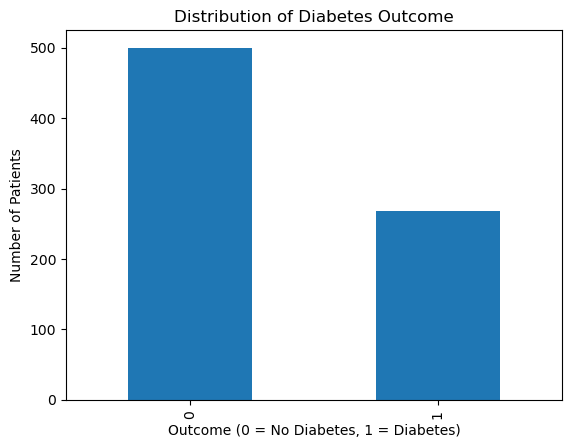

In [25]:
# Visualising the outcome column for possible class imbalance

ax = dataset["Outcome"].value_counts().plot(kind="bar")
plt.title("Distribution of Diabetes Outcome")
plt.xlabel("Outcome (0 = No Diabetes, 1 = Diabetes)")
plt.ylabel("Number of Patients")

plt.show()

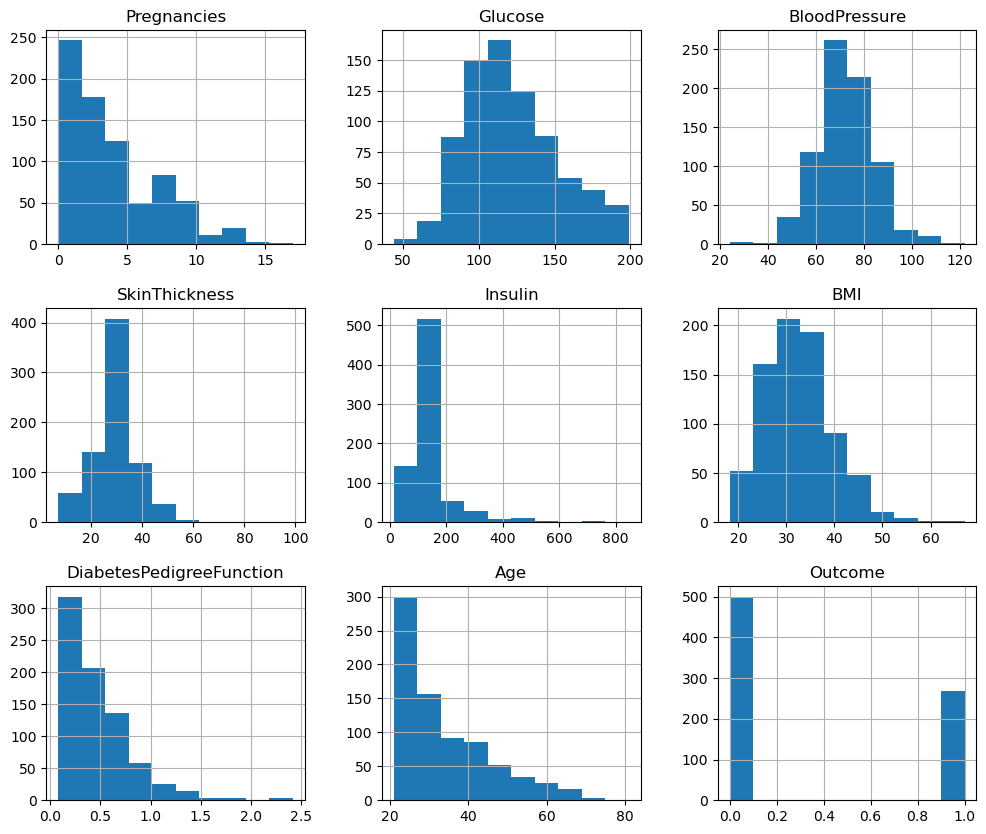

In [26]:
# Univariate Analysis (One Column at a Time) to Understand distributions and spot skewness or outliers.

# Numerical Features

dataset.hist(figsize=(12, 10))
plt.show()

In [27]:
# computing skewness numerically:
dataset.skew()

Pregnancies                 0.901674
Glucose                     0.535587
BloodPressure               0.141885
SkinThickness               0.837608
Insulin                     3.380019
BMI                         0.599233
DiabetesPedigreeFunction    1.919911
Age                         1.129597
Outcome                     0.635017
dtype: float64

In [28]:
# Compute skewness
skew_values = dataset.drop(columns='Outcome').skew()  # Exclude target if you want

# Initialize empty lists
high_skew = []
moderate_skew = []
roughly_symmetric = []

# Loop through each feature and classify
for feature, skew_val in skew_values.items():
    if skew_val >= 1:
        high_skew.append(feature)
    elif skew_val >= 0.5:  # between 0.5 and 1
        moderate_skew.append(feature)
    else:  # skew < 0.5
        roughly_symmetric.append(feature)

# Print results
print("Highly skewed features (>=1):", high_skew)
print("Moderately skewed features (0.5 <= skew < 1):", moderate_skew)
print("Roughly symmetric features (<0.5):", roughly_symmetric)


Highly skewed features (>=1): ['Insulin', 'DiabetesPedigreeFunction', 'Age']
Moderately skewed features (0.5 <= skew < 1): ['Pregnancies', 'Glucose', 'SkinThickness', 'BMI']
Roughly symmetric features (<0.5): ['BloodPressure']


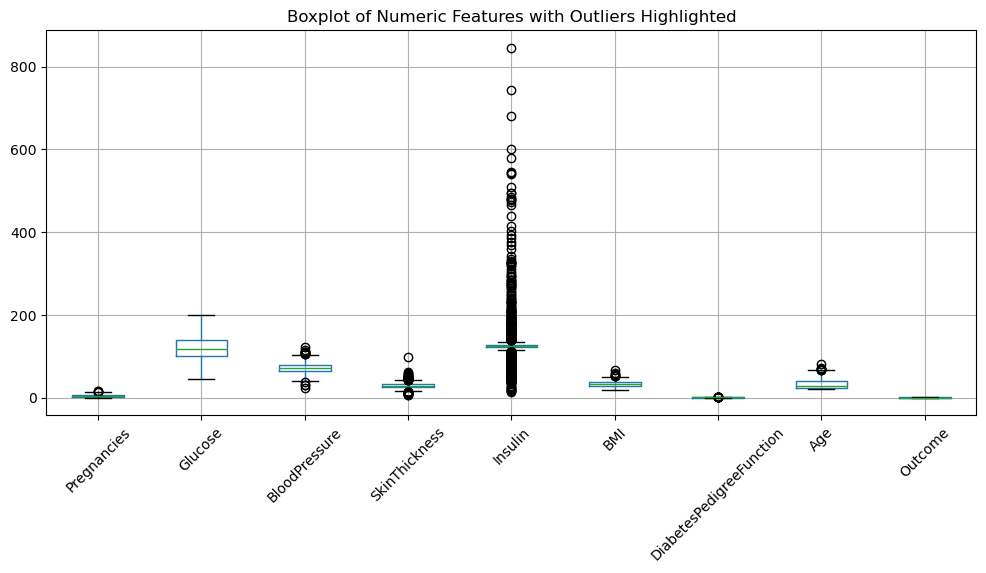

In [35]:
# Boxplots to identify potential outliers across numerical features.
plt.figure(figsize=(12,5))
dataset.boxplot()
plt.xticks(rotation=45)
plt.title("Boxplot of Numeric Features with Outliers Highlighted")
plt.show()

Boxplots were used to identify potential outliers across numerical features.

5️⃣ Feature vs Target Analysis (Most Insightful)

Goal: See how features differ between diabetic and non-diabetic patients.

dataset_clean.groupby("Outcome").median()


Optional plots:

import seaborn as sns

sns.boxplot(x="Outcome", y="Glucose", data=dataset_clean)


📌 What you learn:

Which features separate the classes best

Early hints of feature importance

📝 Notebook line:

Feature distributions were compared across diabetes outcomes to identify patterns associated with diabetes risk.

6️⃣ Correlation Analysis

Goal: Understand relationships between features.

dataset_clean.corr()


Optional heatmap:

sns.heatmap(dataset_clean.corr(), annot=True, cmap="coolwarm")


📌 What you learn:

Strongly correlated features

Potential multicollinearity

📝 Notebook line:

A correlation analysis was performed to explore relationships between numerical features.

🧠 Golden Rule for EDA

EDA should answer questions, not just create visuals.

Always ask:

What does this tell me about diabetes?

Does this affect model choice or preprocessing?

🔥 Minimal EDA (If You Want It Clean & Professional)

If you want to keep it simple and recruiter-friendly, do only:

Target distribution

Feature distributions

Feature vs target comparison

Correlation matrix

That’s more than enough.

1️⃣ Flag Skewed Columns

A feature is considered skewed if its skewness is high (positive or negative).

Skewed features often need transformation (e.g., log, sqrt) before modeling.

# Calculate skewness of each column
skewness = dataset_clean.skew()

# Flag columns with high skew (absolute skew > 1)
skewed_cols = skewness[abs(skewness) > 1].index.tolist()

print("Skewed columns:", skewed_cols)


✅ What this does:

dataset_clean.skew() → calculates skewness for all numeric columns

abs(skewness) > 1 → selects highly skewed columns

skewed_cols → list of skewed columns for potential transformation

2️⃣ Flag Outlier-Prone Columns

We’ll use the IQR method to find extreme values.

outlier_cols = []

for col in dataset_clean.columns[:-1]:  # exclude target
    Q1 = dataset_clean[col].quantile(0.25)
    Q3 = dataset_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = dataset_clean[(dataset_clean[col] < Q1 - 1.5*IQR) | 
                             (dataset_clean[col] > Q3 + 1.5*IQR)]
    if len(outliers) > 0:
        outlier_cols.append(col)

print("Columns with potential outliers:", outlier_cols)


✅ What this does:

Calculates IQR (Q3-Q1) for each column

Flags values below Q1-1.5*IQR or above Q3+1.5*IQR

Keeps a list of columns containing extreme values